# Stage 4: Logistic Regression From Scratch

Goal: extend your linear regression gradient descent implementation to classification — same training loop shape, different output squashing and loss function.

Uses your cleaned Titanic data from Stage 3 (with the leakage fixes: `alive` dropped, imputation/scaling fit after the split).

## 1. Rebuild your cleaned Titanic pipeline

Paste in your fixed Stage 3 pipeline — load, clean, engineer, encode, split, scale. End with `X_train`, `X_val`, `y_train`, `y_val` as NumPy arrays (call `.values` on your DataFrames if needed, since the from-scratch math below expects arrays, not DataFrames).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Load
data = sns.load_dataset('titanic')

# Feature engineer (safe pre-split: pure row-wise arithmetic, no fitted statistics)
data['has_cabin'] = data['deck'].notna()
data['family_size'] = data['sibsp'] + data['parch'] + 1
data['fare_per_person'] = data['fare'] / data['family_size']

# Sex encoding (safe pre-split: deterministic remap, not a fitted statistic)
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

# Drop target leakage columns
X = data.drop(columns=['survived', 'alive'])
y = data['survived']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Impute age (train-only stat, applied to all three splits)
median_age = X_train['age'].median()
X_train['age'] = X_train['age'].fillna(median_age)
X_val['age'] = X_val['age'].fillna(median_age)
X_test['age'] = X_test['age'].fillna(median_age)

# Impute embarked (train-only stat, applied to all three splits)
embarked_mode = X_train['embarked'].mode()[0]
X_train['embarked'] = X_train['embarked'].fillna(embarked_mode)
X_val['embarked'] = X_val['embarked'].fillna(embarked_mode)
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)

# Encode embarked (after imputation, fixed categories so all splits match)
for df in [X_train, X_val, X_test]:
    df['embarked'] = pd.Categorical(df['embarked'], categories=['C', 'Q', 'S'])

X_train = pd.get_dummies(X_train, columns=['embarked'], dtype=int)
X_val = pd.get_dummies(X_val, columns=['embarked'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['embarked'], dtype=int)

# Scale numeric features (fit on train only)
numeric_features = ['age', 'fare', 'family_size', 'fare_per_person']
scaler = RobustScaler()
scaler.fit(X_train[numeric_features])
X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Drop remaining non-numeric/redundant columns your from-scratch math can't use
drop_cols = ['name', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])
X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# Convert to numpy arrays for the from-scratch functions
X_train_np, X_val_np = X_train.values.astype(float), X_val.values.astype(float)
y_train_np, y_val_np = y_train.values.astype(float), y_val.values.astype(float)

print(X_train.columns.tolist())
print(X_train_np.shape, X_val_np.shape)

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'has_cabin', 'family_size', 'fare_per_person', 'embarked_C', 'embarked_Q', 'embarked_S']
(623, 12) (134, 12)


## 2. The sigmoid function

`sigmoid(z) = 1 / (1 + e^-z)`

Guiding question: what input range does `z` (i.e. `X @ w + b`, same as linear regression's raw output) cover, and what range does `sigmoid(z)` squash it into? Why does that make the output interpretable as a probability?

Answer:
- The input range z covers [0,1] and sigmoid squashes it from -1 -> 0 -> 1, this gives us a probability instead of any real number


In [7]:
def sigmoid(z):
    # TODO: implement 1 / (1 + e^-z)
    return 1 / (1 + np.exp(-z))


## 3. The hypothesis function

Same linear combination as before, now passed through sigmoid: `predict_proba(X, w, b) = sigmoid(X @ w + b)`

In [8]:
def predict_proba(X, w, b):
    # TODO: implement sigmoid(X @ w + b)
    return sigmoid(X @ w + b)


## 4. The cost function: log-loss (binary cross-entropy)

`cost = -(1/n) * sum( y*log(y_pred) + (1-y)*log(1-y_pred) )`

Guiding question: why doesn't MSE work well here? (Hint: plug a confidently wrong prediction — e.g. predicted 0.01 when true label is 1 — into both MSE and log-loss by hand and compare how harshly each penalizes it.)

Practical note: add a small epsilon (e.g. `1e-15`) inside the log() calls to avoid `log(0)` errors when a prediction is exactly 0 or 1.

In [9]:
def compute_cost(X, y, w, b):
    # TODO: implement binary cross-entropy using predict_proba() above
    y_pred = predict_proba(X, w, b)
    n = len(y)
    cost = -(1/n) * np.sum( y*np.log(y_pred) + (1-y)*np.log(1-y_pred) )
    return cost


## 5. The gradients

Here's the elegant part: the gradient of log-loss with respect to `w` and `b` works out to the *exact same form* as linear regression's gradient:
- `dw = (1/n) * X.T @ (y_pred - y_true)`
- `db = (1/n) * sum(y_pred - y_true)`

The only difference is `y_pred` now comes from `sigmoid(X @ w + b)` instead of `X @ w + b` directly.

Guiding question: this is a genuinely nice result — the sigmoid and log-loss were specifically chosen because their derivatives cancel out this cleanly. You don't need to re-derive the full chain rule from scratch here, but do trace through *why* the gradient has this same shape as linear regression's, given the different cost function.

In [10]:
def compute_gradients(X, y, w, b):
    # TODO: implement dw, db (same formula shape as linear regression, using predict_proba)
    y_pred = predict_proba(X, w, b)
    error = y_pred-y
    n = len(y)

    dw = (1/n) * X.T @(error)
    db = (1/n) * sum(error)


    return dw,db


## 6. Training loop

This should look almost identical to your linear regression training loop — that's the point. Reuse the structure.

In [11]:
def train_logistic_regression(X, y, learning_rate=0.01, n_iterations=1000):
    # TODO: initialize w, b, loop n_iterations: compute gradients, update, record cost
    # return final w, b, cost history

     w = np.zeros(X.shape[1])
     b = 0
     cost = []

     for i in range(n_iterations):
          dw,db = compute_gradients(X,y,w,b)
          w -= learning_rate * dw
          b -= learning_rate * db
          current_cost = compute_cost(X,y,w,b)
          cost.append(current_cost)

     return w,b,cost


## 7. Train and plot the loss curve

Same sanity checks as linear regression: does the curve decrease and flatten? Try a couple learning rates if it doesn't converge cleanly.

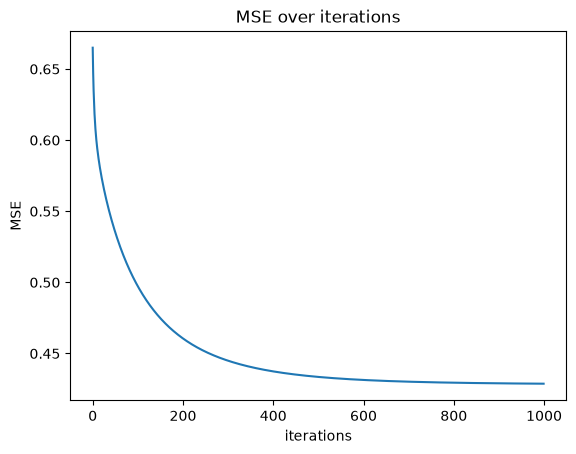

In [16]:
# TODO: train, plot cost history


w, b, cost = train_logistic_regression(X_train_np, y_train_np, learning_rate=0.1, n_iterations=1000)


plt.plot(cost)
plt.xlabel("iterations")
plt.ylabel("MSE")
plt.title("MSE over iterations")
plt.show()


## 8. Convert probabilities to hard predictions and check accuracy

Threshold `predict_proba()` output at 0.5 to get 0/1 labels, then compute accuracy manually (fraction correct). Full precision/recall/F1/ROC-AUC treatment comes next in Stage 5 — accuracy alone is enough here just to sanity-check your implementation works.

In [22]:
# TODO: threshold at 0.5, compute accuracy on X_val

y_val_proba = predict_proba(X_val_np, w, b)
y_val_pred = (y_val_proba >= 0.5).astype(int)
print(y_val_proba[:5])
print(y_val_pred[:5])
correct = np.sum(y_val_pred == y_val)
accuracy = correct / len(y_val)
print(f"Validation accuracy: {accuracy:.4f}")


[0.81894445 0.12557758 0.25855105 0.56271604 0.2911819 ]
[1 0 0 1 0]
Validation accuracy: 0.8507


## 9. Compare against scikit-learn

Fit `sklearn.linear_model.LogisticRegression` on the same data.

Guiding question: do your `w`/`b` and accuracy roughly match sklearn's? (Note: sklearn applies L2 regularization by default, which linear regression's plain OLS didn't have — small differences here are expected and fine; you can pass `penalty=None` to sklearn for a closer apples-to-apples comparison if you want to verify precisely.)

In [23]:
from sklearn.linear_model import LogisticRegression

# TODO: fit sklearn's LogisticRegression, compare coefficients and accuracy

model = LogisticRegression()
model.fit(X_train_np, y_train_np,)
y_val_pred_sklearn = model.predict(X_val_np)


sklearn_accuracy = (y_val_pred_sklearn == y_val_np).mean()

print("Your from-scratch w:", w)
print("sklearn's coef_:    ", model.coef_)
print()
print("Your from-scratch b:", b)
print("sklearn's intercept_:", model.intercept_)
print()
print("Your from-scratch accuracy:", accuracy)
print("sklearn accuracy:         ", sklearn_accuracy)








Your from-scratch w: [-0.72239179  2.55734259 -0.60507001 -0.20187246  0.05111857  0.16181711
  0.99000773 -0.15075389 -0.06335114  0.09209897  0.31252449 -0.1870891 ]
sklearn's coef_:     [[-0.75798359  2.53195253 -0.61102405 -0.19726373  0.05583547  0.12599391
   1.00114101 -0.14142826 -0.04919033 -0.00957987  0.28497138 -0.27169953]]

Your from-scratch b: 0.2175343640431354
sklearn's intercept_: [0.39074487]

Your from-scratch accuracy: 0.8507462686567164
sklearn accuracy:          0.8582089552238806


## Wrap-up

Write a short summary: how similar was this implementation to linear regression's? What specifically changed (2-3 things), and what stayed exactly the same? This comparison is the actual learning goal of this notebook.

_Your summary here._
- This was similar to linear regression, the pipeline is generally the same, explore the data, engineer features, train, predict, evaulate. However, at each stage the implementation is a bit different (training is similar). Logistic Regression is mainly used for binary classification ( [0,1], [false,true], [yes,no]...) while linear regression is used for continous values. 
- Changes:
    - Sigmoid squashing X @ w + b into a probability, where linear regression just used the raw output directly
    - Log-loss as the cost function instead of MSE

- Similarities:
    - The gradient formula itself — dw = (1/n) * X.T @ (y_pred - y_true) — is identical in shape between the two, just with a different y_pred
    - The entire training loop structure (init weights, loop, compute gradients, step, record cost)
